## imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.spatial.distance import euclidean
from scipy.spatial.distance import cdist
import collections
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from wordcloud import WordCloud, get_single_color_func
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA
import random
import os
import pickle
import re
from num2words import num2words
from scipy.stats import pearsonr

cmap = plt.cm.Spectral
%matplotlib inline

## set paths

In [2]:
annot_dir = '../../data/annotations_dfs/'
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings', 'k:1000')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings', 'k:1000')
pickle_dir = '../../data/pickles/'
fig_dir = '../../figures/'

## define some functions

In [3]:
def format_episode_text(textlist):
    """
    takes care of standardizing annotation text format for modeling
    """
    new_textlist = []
    
    for chunk in textlist:
        
        new_chunks = []
        for subchunk in chunk.split(','):
            # remove all characters except letters, spaces, apostrophes, dashes. Put all in uppercase
            upper_nopunc = re.sub("[^\w\s'-]+", '', subchunk.upper())

            # remove accented characters
            no_acc = upper_nopunc.replace('É', 'E')

            # convert digits to numbers
            if any(word.isdigit() for word in no_acc.split(' ')):
                for word in no_acc.split(' '):
                    if word.isdigit():
                        no_acc = no_acc.replace(word, num2words(int(word)).upper())
                    
            new_chunks.append(no_acc)
        
        new_textlist.append(','.join(new_chunks))
    
    return new_textlist

In [4]:
def text2dict(text):
    cv = CountVectorizer(stop_words='english')
    cv_text = cv.fit_transform(text)
    return {k:v for k,v in zip(cv.get_feature_names(), cv_text.toarray().ravel())}

In [5]:
def topn(d, n):
    c = collections.Counter(d)
    return {k:v for k, v in c.most_common(n)}

In [6]:
def get_normalized_model(m, tm):
    m = np.dot(m, tm.components_)
    m-=m.mean(0)
    m-=np.min(m)
    m/=np.max(m)
    return m

In [7]:
class SimpleGroupedColorFunc(object):
    """Create a color function object which assigns EXACT colors
       to certain words based on the color to words mapping
       Parameters
       ----------
       color_to_words : dict(str -> list(str))
         A dictionary that maps a color to the list of words.
       default_color : str
         Color that will be assigned to a word that's not a member
         of any value from color_to_words.
    """

    def __init__(self, color_to_words, default_color):
        self.word_to_color = {word: color
                              for (color, words) in color_to_words.items()
                              for word in words}

        self.default_color = default_color

    def __call__(self, word, **kwargs):
        return self.word_to_color.get(word, self.default_color)

In [8]:
def plot_wordle(ax, textdict, maskpath=None):
    circle = np.array(Image.open(maskpath))
    wc = WordCloud(max_font_size=50, collocations=False, max_words=200, background_color="white", mask=circle, width=2000, height=1000, colormap=plt.cm.Reds)
    wc.generate_from_frequencies(textdict)
    ax.imshow(wc.recolor(color_func=grouped_color_func, random_state=3),
           interpolation="bilinear")
    ax.axis("off")

In [9]:
def plot_image(x, y, image, ax=None, zoom=1):
    if ax is None:
        ax = plt.gca()
    try:
        image = plt.imread(image)
    except TypeError:
        pass
    im = OffsetImage(image, zoom=zoom)
    x, y = np.atleast_1d(x, y)
    im.image.axes=ax
    artists = []
    ab = AnnotationBbox(im, (x, y), xycoords='data', frameon=False)
    artists.append(ax.add_artist(ab))
#     ax.update_datalim(np.column_stack([x, y]))
#     ax.autoscale()
    return artists

In [10]:
def add_arrows(axes, x, y, **kwargs):

    # spacing of arrows
    aspace = .05 # good value for scale of 1
    aspace *= scale

    # r is the distance spanned between pairs of points
    r = [0]
    for i in range(1,len(x)):
        dx = x[i]-x[i-1]
        dy = y[i]-y[i-1]
        r.append(np.sqrt(dx*dx+dy*dy))
    r = np.array(r)

    # rtot is a cumulative sum of r, it's used to save time
    rtot = []
    for i in range(len(r)):
        rtot.append(r[0:i].sum())
    rtot.append(r.sum())

    arrowData = [] # will hold tuples of x,y,theta for each arrow
    arrowPos = 0 # current point on walk along data
    rcount = 1 
    while arrowPos < r.sum():
        x1,x2 = x[rcount-1],x[rcount]
        y1,y2 = y[rcount-1],y[rcount]
        da = arrowPos-rtot[rcount] 
        theta = np.arctan2((x2-x1),(y2-y1))
        ax = np.sin(theta)*da+x1
        ay = np.cos(theta)*da+y1
        arrowData.append((ax,ay,theta))
        arrowPos+=aspace
        while arrowPos > rtot[rcount+1]: 
            rcount+=1
            if arrowPos > rtot[-1]:
                break

    # could be done in above block if you want
    for ax,ay,theta in arrowData:
        # use aspace as a guide for size and length of things
        # scaling factors were chosen by experimenting a bit
        axes.arrow(ax,ay,
                   np.sin(theta)*aspace/10,np.cos(theta)*aspace/10, 
                   head_width=aspace/3, **kwargs)

In [11]:
## for plotting error bars
def ribbon(M, color='k', alpha=0.5, label=None):    
    x = np.arange(M.shape[0])
    y = np.mean(M, axis=1)
    ci = 1.96 * np.divide(np.std(M, axis=1), np.sqrt(M.shape[1] - 1))
    
    h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color, label=label)
    return h1, h2

In [12]:
def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [13]:
def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [14]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs: : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values

    """
    return _z2r(np.nanmean([_r2z(r) for r in rs], axis=axis))

## load data

In [15]:
# episode annotations
atlep1_df = pd.read_pickle(annot_dir+'atlep1.p')
atlep2_df = pd.read_pickle(annot_dir+'atlep2.p')
arrdev_df = pd.read_pickle(annot_dir+'arrdev.p')

# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir, topdown=True):
    dirs[:] = [d for d in dirs if d not in ['vidwProp', 'vidwProp_recwProp']]
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}


# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

## find events best remembered

In [16]:
# include delayed recalls
episode_events['delayed'] = episode_events['atlep1']

In [17]:
# ep_rec_dists = {k : None for k in episode_events.keys()}

# # each participant's events
# for episode, episode_es in episode_events.items():
#     dists = []
#     for ep_e in episode_es:
#         dist = []
#         for turkid, sub in participant_events[episode]:
#             dist.append(np.max(1-cdist(np.atleast_2d(ep_e), sub, 'correlation')))
#         dists.append(dist)
#     ep_rec_dists[episode] = np.array(dists)
#     df = pd.DataFrame(dists)
#     df = df.melt(var_name='subject', value_name='Average correlation')
#     df['Event number'] = list(range(episode_es.shape[0]))*(df.subject.max()+1)
#     sns.lineplot(x='Event number', y='Average correlation', data=df)
#     plt.title(episode)
#     plt.xlim(0, episode_es.shape[0]-1)
#     plt.ylim(0,1)
#     plt.show()

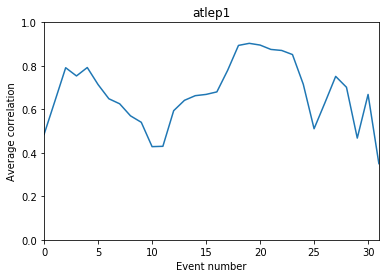

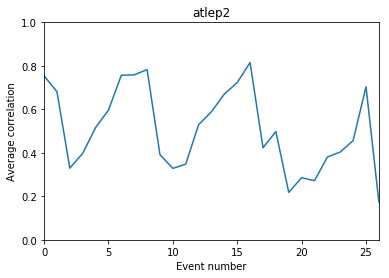

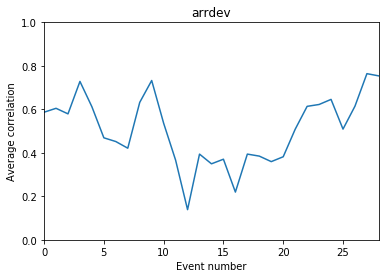

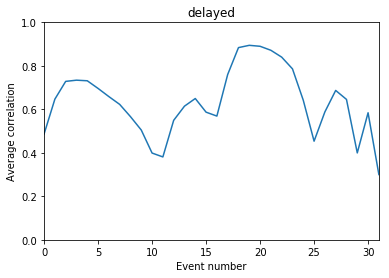

In [18]:
# z-transforming means
ep_rec_dists = {k : None for k in episode_events.keys()}

# each participant's events
for episode, episode_es in episode_events.items():
    dists = []
    for ep_e in episode_es:
        dist = []
        for turkid, sub in participant_events[episode]:
            dist.append(np.max(1-cdist(np.atleast_2d(ep_e), sub, 'correlation')))
        dists.append(dist)
    ep_rec_dists[episode] = np.array(dists)
    df = pd.DataFrame(dists)
    df['Average correlation'] = _z2r(_r2z(pd.DataFrame(dists)).mean(axis=1))
#     df = df.melt(var_name='subject', value_name='Average correlation')
#     df['Event number'] = list(range(episode_es.shape[0]))*(df.subject.max()+1)
    df['Event number'] = df.index
    sns.lineplot(x='Event number', y='Average correlation', data=df)
    plt.title(episode)
    plt.xlim(0, episode_es.shape[0]-1)
    plt.ylim(0,1)
    plt.show()

In [54]:
# # using average participant events instead
# for episode, episode_es in episode_events.items():
#     dists_a = []
#     for ep_e in episode_es:
#         dists_a.append(np.nanmax(1-cdist(np.atleast_2d(ep_e), avg_participant_events[episode], 'correlation')))
#     df = pd.DataFrame([list(range(len(dists_a))), dists_a]).T
#     df.columns = ['Event number', 'Average correlation']
#     sns.lineplot(x='Event number', y='Average correlation', data=df)
#     plt.title(episode)
#     plt.xlim(0, episode_es.shape[0]-1)
#     plt.ylim(0.5,1)
#     plt.show()

## find events remembered better/worse after delay than immediately

In [130]:
immediate_corr = np.diag(1-cdist(avg_participant_events['atlep1'], episode_events['atlep1'], 
                                   metric='correlation'))
delayed_corr = np.diag(1-cdist(avg_participant_events['delayed'], episode_events['atlep1'], 
                                   metric='correlation'))

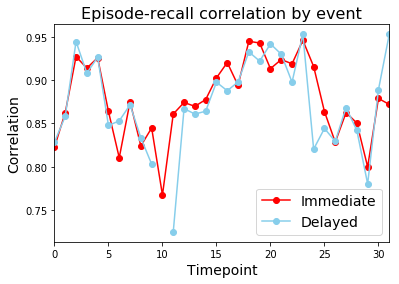

In [131]:
plt.plot(immediate_corr, color='red', label='Immediate', marker='o')
plt.plot(delayed_corr, color='skyblue', label='Delayed', marker='o')
plt.xlim((0,31))
# plt.ylim((0.6,1))
plt.title('Episode-recall correlation by event', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Correlation', fontsize=14)
plt.legend(fontsize=14)
# plt.savefig(fig_dir+'immediate-delayed-analyses/immediate-delayed-ep-rec-corr_events.pdf')

Text(0.5,1,'Memory accuracy change by event')

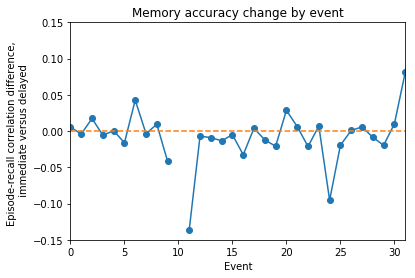

In [132]:
plt.plot(delayed_corr-immediate_corr, marker='o')
plt.plot([0,31], [0,0], linestyle='--')
plt.xlim((0,31))
plt.ylim((-.15,.15))
plt.xlabel('Event')
plt.ylabel('Episode-recall correlation difference, \n immediate versus delayed')
plt.title('Memory accuracy change by event')
# plt.savefig(fig_dir+'immediate-delayed-analyses/accuracy_diff_by_event.pdf')

## create and fit CountVectorizer and LatentDirichletAllocation models

In [19]:
atlep1_text = format_episode_text(atlep1_df.loc[:,'Narrative details (external events)':'Setting'].apply(
        lambda x: ', '.join(x.fillna('')), axis=1).values.tolist())
atlep1_cv = CountVectorizer(stop_words='english')
atlep1_fitcv = atlep1_cv.fit_transform(atlep1_text)
atlep1_tm = LDA(n_components=100, learning_method='batch', random_state=0).fit(atlep1_fitcv)

atlep2_text = format_episode_text(atlep2_df.loc[:,'Narrative details (external events)':'Setting'].apply(
        lambda x: ', '.join(x.fillna('')), axis=1).values.tolist())
atlep2_cv = CountVectorizer(stop_words='english')
atlep2_fitcv = atlep2_cv.fit_transform(atlep2_text)
atlep2_tm = LDA(n_components=100, learning_method='batch', random_state=0).fit(atlep2_fitcv)


arrdev_text = format_episode_text(arrdev_df.loc[:,'Narrative details (external events)':'Setting'].apply(
        lambda x: ', '.join(x.fillna('')), axis=1).values.tolist())
arrdev_cv = CountVectorizer(stop_words='english')
arrdev_fitcv = arrdev_cv.fit_transform(arrdev_text)
arrdev_tm = LDA(n_components=100, learning_method='batch', random_state=0).fit(arrdev_fitcv)


## normalize models

In [20]:
norm_atlep1_events = get_normalized_model(episode_events['atlep1'], atlep1_tm)
norm_atlep1_avg_recall_events = get_normalized_model(avg_participant_events['atlep1'], atlep1_tm)

norm_atlep2_events = get_normalized_model(episode_events['atlep2'], atlep2_tm)
norm_atlep2_avg_recall_events = get_normalized_model(avg_participant_events['atlep2'], atlep2_tm)

norm_arrdev_events = get_normalized_model(episode_events['arrdev'], arrdev_tm)
norm_arrdev_avg_recall_events = get_normalized_model(avg_participant_events['arrdev'], arrdev_tm)

norm_delayed_events = get_normalized_model(episode_events['delayed'], atlep1_tm)
norm_delayed_avg_recall_events = get_normalized_model(avg_participant_events['delayed'], atlep1_tm)

## organize

In [21]:
events_keys = ['cv', 'fit_cv', 'tm', 'norm_ep_events', 'norm_avg_rec_events']
events_dict = {ep : {} for ep in episode_events.keys()}

events_dict['atlep1'] = {k : v for k, v in zip(events_keys, [atlep1_cv, atlep1_fitcv, atlep1_tm, norm_atlep1_events,
                                                          norm_atlep1_avg_recall_events])}
events_dict['atlep2'] = {k : v for k, v in zip(events_keys, [atlep2_cv, atlep2_fitcv, atlep2_tm, norm_atlep2_events,
                                                          norm_atlep2_avg_recall_events])}
events_dict['arrdev'] = {k : v for k, v in zip(events_keys, [arrdev_cv, arrdev_fitcv, arrdev_tm, norm_arrdev_events,
                                                          norm_arrdev_avg_recall_events])}
events_dict['delayed'] = {k : v for k, v in zip(events_keys, [atlep1_cv, atlep1_fitcv, atlep1_tm, norm_delayed_events,
                                                          norm_delayed_avg_recall_events])}

## wordle figures

In [22]:
## parameters for figs
default_color = 'grey'
n_words_ev = 50
n_words_ep = 200
seed = 15
wordlefig_dir = fig_dir+'wordles/'
hml_mask = wordlefig_dir+'half-moon-left.jpg'
hmr_mask = wordlefig_dir+'half-moon-right.jpg'
oval_mask = wordlefig_dir+'oval.jpg'

In [23]:
# for episode, episode_es in episode_events.items():
#     data = events_dict[episode]
#     for event in range(episode_es.shape[0]):
#         e_weights = data['norm_ep_events'][event]
#         textdict_episode = topn({word : weight for word, weight in zip(data['cv'].get_feature_names(), e_weights)},
#                                 n_words_ev)
#         r_weights = data['norm_avg_rec_events'][event]
#         textdict_recall = topn({word : weight for word, weight in zip(data['cv'].get_feature_names(), r_weights)},
#                                n_words_ev)
#         fig, (ax1, ax2) = plt.subplots(1, 2)
#         color_to_words = {'black': list(set(textdict_episode))}
#         grouped_color_func = SimpleGroupedColorFunc(color_to_words, default_color)
#         plot_wordle(ax1, textdict_episode, maskpath=hml_mask)
#         plot_wordle(ax2, textdict_recall, maskpath=hmr_mask)
#         plt.subplots_adjust(wspace=-.5, hspace=-.5)
#         fig.patch.set_visible(False)
#         plt.savefig(wordlefig_dir+'{0}/wordle_event{1}.png'.format(episode, event), dpi=300)
#         plt.close()

## weighted average of event vectors by memorability

In [23]:
episode_weights = {k : None for k in episode_events.keys()}
for episode, dists in ep_rec_dists.items():
    mdist = corr_mean(dists, axis=1)
    rvec = np.zeros_like(episode_events[episode][0])
    fvec = np.zeros_like(episode_events[episode][0])
    rsum = 0
    fsum = 0
    for v, w in zip(episode_events[episode], mdist):
        rvec += v*w
        rsum += w
        fvec += v*(1-w)
        fsum += (1-w)
    
    r = rvec/rsum
    r =  r - episode_events[episode].mean(0)
    f = fvec/fsum
    f = f - episode_events[episode].mean(0)
    episode_weights[episode] = {'r' : r, 'f' : f, 'mdist' : mdist}

## most memorable topics from each episode

In [27]:
# for episode, weights in episode_weights.items():
#     rweights = np.dot(weights['r'], events_dict[episode]['tm'].components_)
#     rdict = topn({word : weight for word, weight in zip(events_dict[episode]['cv'].get_feature_names(), 
#                                                         rweights)}, n=n_words_ep)
#     fig, ax1 = plt.subplots(1,1)
#     color_to_words = {'black': list(set(rdict))}
#     grouped_color_func = SimpleGroupedColorFunc(color_to_words, default_color)
#     plot_wordle(ax1, rdict, maskpath=oval_mask)
# #     plt.savefig(wordlefig_dir+'{0}/most_remembered_{1}.pdf'.format(episode, n_words_ep))
#     plt.show()

## least memorable topics from each episode

In [140]:
# for episode, weights in episode_weights.items():
#     fweights = np.dot(weights['f'], events_dict[episode]['tm'].components_)
#     fdict = topn({word : weight for word, weight in zip(events_dict[episode]['cv'].get_feature_names(), 
#                                                         fweights)}, n=n_words_ep)
#     fig, ax1 = plt.subplots(1,1)
#     color_to_words = {'black': list(set(fdict))}
#     grouped_color_func = SimpleGroupedColorFunc(color_to_words, default_color)
#     plot_wordle(ax1, fdict, maskpath=oval_mask)
#     plt.savefig(wordlefig_dir+'{0}/least_remembered_{1}.pdf'.format(episode, n_words_ep))
#     plt.show()

**- imm r minus del r tells you topic vector direction you were "pulled FROM" over course of delay**
**- correlate that vector with each event vector in movie, see which it's most similar to. This tells you part of movie that had biggest impact immediately that was lost after delay**

**- del r minus imm r tells you opposite. Tells you opposite -- "what event came into focus over course of week"**

**- analysis with worst remembered events is "stuff that was blocked out after immediate that you didn't block out after delay"**


## What content had the largest immediate impact that was lost over the course of the delay?

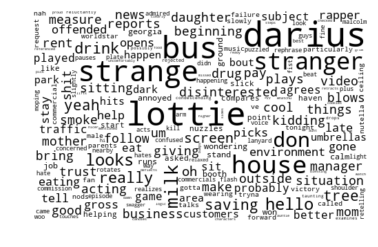

In [76]:
imm_weights = episode_weights['atlep1']
del_weights = episode_weights['delayed']

away_from_r = imm_weights['r'] - del_weights['r']
away_from_rweights = np.dot(away_from_r, events_dict['atlep1']['tm'].components_)

away_from_dict = topn({word : weight for word, weight in zip(events_dict['atlep1']['cv'].get_feature_names(), 
                                                        away_from_rweights)}, n=n_words_ep)
fig, ax1 = plt.subplots(1,1)
color_to_words = {'black': list(set(away_from_dict))}
grouped_color_func = SimpleGroupedColorFunc(color_to_words, default_color)
plot_wordle(ax1, away_from_dict, maskpath=oval_mask)
plt.savefig(wordlefig_dir+'content_pulled_from.pdf')
plt.show()

## which event is most similar to the topic vector of lost content?

In [75]:
ix = np.argmax(1-cdist(episode_events['atlep1'], np.atleast_2d(away_from_r), 'correlation'))
print('event {}'.format(ix))

event 29


## What content came into focus most over the course of the delay?

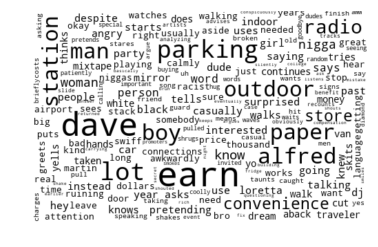

In [78]:
toward_r = del_weights['r'] - imm_weights['r']
toward_rweights = np.dot(toward_r, events_dict['atlep1']['tm'].components_)

toward_dict = topn({word : weight for word, weight in zip(events_dict['atlep1']['cv'].get_feature_names(), 
                                                        toward_rweights)}, n=n_words_ep)
fig, ax1 = plt.subplots(1,1)
color_to_words = {'black': list(set(toward_dict))}
grouped_color_func = SimpleGroupedColorFunc(color_to_words, default_color)
plot_wordle(ax1, toward_dict, maskpath=oval_mask)
plt.savefig(wordlefig_dir+'content_pulled_toward.pdf')
plt.show()

## which event is most similar to the topic vector of re-focused content?

In [79]:
ix = np.argmax(1-cdist(episode_events['atlep1'], np.atleast_2d(toward_r), 'correlation'))
print('event {}'.format(ix))

event 20


## topics best preserved from immediate to delay (updated method above)

In [72]:
# # words whose delayed weights are closest to their immediate weights
# imm_weights = episode_weights['atlep1']
# del_weights = episode_weights['delayed']

# imm_rweights = np.dot(imm_weights['r'], events_dict['atlep1']['tm'].components_)
# del_rweights = np.dot(del_weights['r'], events_dict['delayed']['tm'].components_)

# imm_rdict = topn({word : weight for word, weight in zip(events_dict['atlep1']['cv'].get_feature_names(), 
#                                                         imm_rweights)}, n=None)
# del_rdict = topn({word : weight for word, weight in zip(events_dict['delayed']['cv'].get_feature_names(), 
#                                                         del_rweights)}, n=None)

# pres_dict = topn({word : imm_rdict[word]-del_rdict[word] for word in imm_rdict.keys() 
#                   if imm_rdict[word]-del_rdict[word] > 0}, n=n_words_ep)

# fig, ax1 = plt.subplots(1,1)
# color_to_words = {'black': list(set(pres_dict))}
# grouped_color_func = SimpleGroupedColorFunc(color_to_words, default_color)
# plot_wordle(ax1, pres_dict, maskpath=oval_mask)
# # plt.savefig(wordlefig_dir+'best-preserved.pdf')
# plt.show()

## content remembered *better* in delayed than immediate
### (i.e. content "blocked out" during immediate recall, but not during delayed recall)

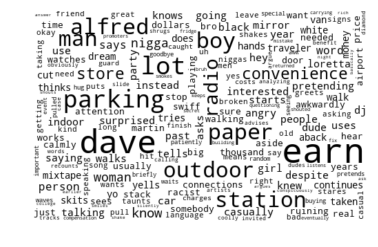

In [80]:
# higher "remembered" weights
more_del_dict = topn({word : del_rdict[word]-imm_rdict[word] for word in imm_rdict.keys() 
                  if del_rdict[word]-imm_rdict[word] > 0}, n=n_words_ep)

fig, ax1 = plt.subplots(1,1)
color_to_words = {'black': list(set(more_del_dict))}
grouped_color_func = SimpleGroupedColorFunc(color_to_words, default_color)
plot_wordle(ax1, more_del_dict, maskpath=oval_mask)
plt.savefig(wordlefig_dir+'stronger-delayed.pdf')
plt.show()

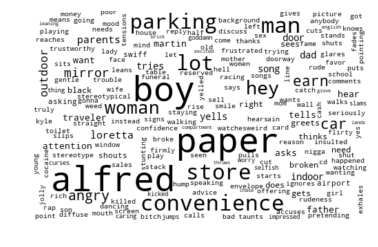

In [81]:
# lower "forgotten" weights
imm_fweights = np.dot(imm_weights['f'], events_dict['atlep1']['tm'].components_)
del_fweights = np.dot(del_weights['f'], events_dict['delayed']['tm'].components_)

imm_fdict = topn({word : weight for word, weight in zip(events_dict['atlep1']['cv'].get_feature_names(), 
                                                        imm_fweights)}, n=None)
del_fdict = topn({word : weight for word, weight in zip(events_dict['delayed']['cv'].get_feature_names(), 
                                                        del_fweights)}, n=None)

less_fdel_dict = topn({word : imm_fdict[word]-del_fdict[word] for word in imm_fdict.keys() 
                  if imm_fdict[word]-del_fdict[word] > 0}, n=n_words_ep)

fig, ax1 = plt.subplots(1,1)
color_to_words = {'black': list(set(less_fdel_dict))}
grouped_color_func = SimpleGroupedColorFunc(color_to_words, default_color)
plot_wordle(ax1, less_fdel_dict, maskpath=oval_mask)
# plt.savefig(wordlefig_dir+'less-forgotten.pdf')
plt.show()

In [71]:
# sns.jointplot(x=list(imm_rdict.values()), y=list(del_rdict.values()), kind='reg', stat_func=pearsonr)

## Trajectory distribution figures

### load UMAP embeddings

In [83]:
embeddings_dict = {'atlep1' : None, 'atlep2' : None, 'arrdev' : None} #, 'delayed': None, 'prediction' : None}


for rectype in embeddings_dict.keys():
    embeddings_dict[rectype] = {'episode_events' : None, 'avg_participant_events' : None, 'participant_events' : None}
        
    embeddings_dict[rectype]['episode_events'] = np.load(os.path.join(ep_emb_dir,rectype+'-events.npy'))
    
    embeddings_dict[rectype]['avg_participant_events'] = np.load(os.path.join(rec_emb_dir,rectype,
                                                                              'avg_participant_events.npy'))
    
    individuals = []
    for f_name in [f for f in os.listdir(os.path.join(rec_emb_dir,rectype)) if f.startswith('debug')]:
        individuals.append((os.path.splitext(f_name)[0], np.load(os.path.join(rec_emb_dir,rectype,f_name))))
    embeddings_dict[rectype]['participant_events'] = individuals

In [66]:
# for rectype in embeddings_dict.keys():
#     ep_embeddings = embeddings_dict[rectype]['episode_events']
#     rec_embeddings = embeddings_dict[rectype]['participant_events']
#     mdist = episode_weights[rectype]['mdist']
    
#     fig = plt.figure(figsize=(9,6))
#     ax = fig.add_subplot(111)
#     scale = 10
#     for i, (turkid, sub) in enumerate(rec_embeddings):
#         sub_match = next(matches for (tid, matches) in event_mappings[rectype] if tid==turkid)
#         for j, (p, m) in enumerate(zip(sub, sub_match)):
#             ax.plot(p[0], p[1], 'o', c=cmap(m/ep_embeddings.shape[0]), alpha=.75, zorder=2, markersize=7)
#             ax.plot(p[0], p[1], 'o', c='k', alpha=.5, zorder=1, markersize=8)
#     for i in range(ep_embeddings.shape[0]-1):
#         ax.plot([ep_embeddings[i,0], ep_embeddings[i+1,0]], 
#                 [ep_embeddings[i,1], ep_embeddings[i+1,1]], c='k', linewidth=2, alpha=1)
#     for i in range(ep_embeddings.shape[0]-1):
#         ax.plot(ep_embeddings[i,0], ep_embeddings[i,1], 'o', c=cmap(i/ep_embeddings.shape[0]), 
#                 zorder=4, markersize=mdist[i]*scale+5, alpha=.9)
#         ax.plot(ep_embeddings[i,0], ep_embeddings[i,1], 'ko', zorder=3, markersize=mdist[i]*scale+7, alpha=.9)
#     add_arrows(ax, ep_embeddings[:,0], ep_embeddings[:,1], zorder=3, alpha=1, color='k', fill=True)
#     ax.axis('off')
#     plt.show()

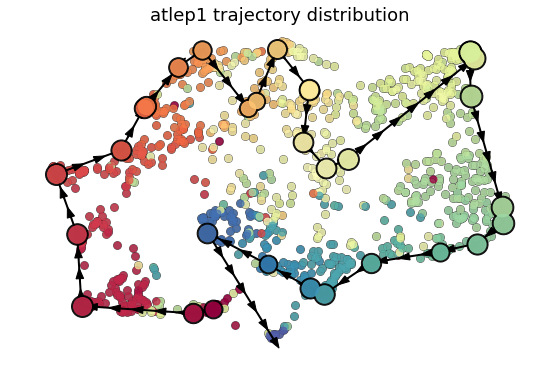

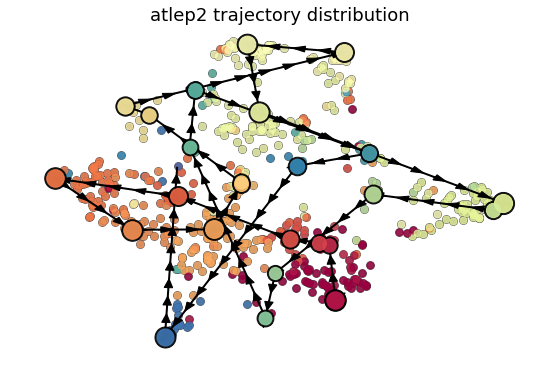

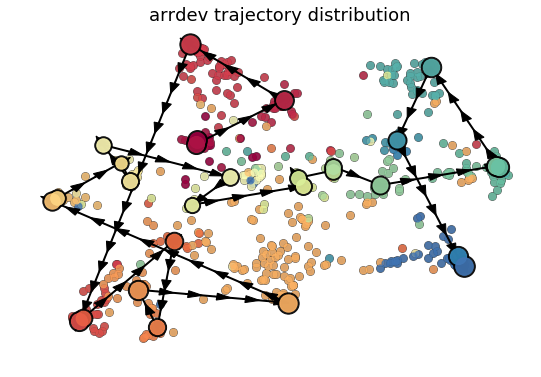

In [86]:
# fig = plt.figure(figsize=(9,20))
for sp, rectype in enumerate(embeddings_dict.keys()):
    ep_embeddings = embeddings_dict[rectype]['episode_events']
    rec_embeddings = embeddings_dict[rectype]['participant_events']
    mdist = episode_weights[rectype]['mdist']
    fig = plt.figure(figsize=(9,6))
#     ax = fig.add_subplot(3,1,sp+1)
    ax = fig.add_subplot(1,1,1)
    scale = 10
    for i, (turkid, sub) in enumerate(rec_embeddings):
        sub_match = next(matches for (tid, matches) in event_mappings[rectype] if tid==turkid)
        for j, (p, m) in enumerate(zip(sub, sub_match)):
            ax.plot(p[0], p[1], 'o', c=cmap(m/ep_embeddings.shape[0]), alpha=.75, zorder=2, markersize=7)
            ax.plot(p[0], p[1], 'o', c='k', alpha=.5, zorder=1, markersize=8)
    for i in range(ep_embeddings.shape[0]-1):
        ax.plot([ep_embeddings[i,0], ep_embeddings[i+1,0]], 
                [ep_embeddings[i,1], ep_embeddings[i+1,1]], c='k', linewidth=2, alpha=1)
    for i in range(ep_embeddings.shape[0]-1):
        ax.plot(ep_embeddings[i,0], ep_embeddings[i,1], 'o', c=cmap(i/ep_embeddings.shape[0]), 
                zorder=4, markersize=mdist[i]*scale+10, alpha=.9)
        ax.plot(ep_embeddings[i,0], ep_embeddings[i,1], 'ko', zorder=3, markersize=mdist[i]*scale+14, alpha=.9)
    add_arrows(ax, ep_embeddings[:,0], ep_embeddings[:,1], zorder=3, alpha=1, color='k', fill=True)
    ax.axis('off')
    ax.set_title(rectype + ' trajectory distribution', fontsize=18)
    plt.savefig(wordlefig_dir+'{0}/{0}_trajectory_distribution_seed{1}.pdf'.format(rectype, seed))
    plt.show()
# plt.savefig(wordlefig_dir+'trajectory_distributions_seed{0}.pdf'.format(seed))
# plt.show()